# CIFAR-10 EDA — Autoencoders (Denoising)

**Dataset:** CIFAR-10 (Krizhevsky, 2009)  
**Source:** 60,000 color images (32×32×3), 10 object classes  
**Samples:** 60,000 (50K train / 10K test) | **Features:** 3,072 (flattened) | **Target:** 10 classes (labels for evaluation only)  
**Task:** Learn compressed representations via autoencoder reconstruction — first self-supervised model in the project

## Purpose
Inspect raw data before preprocessing:
- Verify pixel distributions and data types across RGB channels
- Confirm class balance (CIFAR-10 is perfectly balanced)
- Analyze image complexity and spatial structure per class
- Assess compression ratio feasibility for latent dimensions
- Preview noise corruption at different σ levels for denoising task
- Every finding maps to a specific preprocessing decision

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration
RANDOM_STATE = 113
np.random.seed(RANDOM_STATE)
EDA_DIR = '../data/raw/eda_autoencoder'
os.makedirs(EDA_DIR, exist_ok=True)

# CIFAR-10 class names (index matches label 0-9)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Download CIFAR-10 via Keras (cached after first download)
from tensorflow.keras.datasets import cifar10
(X_train_raw, y_train), (X_test_raw, y_test) = cifar10.load_data()

# Keras returns labels as (N, 1) — flatten to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("=" * 60)
print("CIFAR-10 — Raw Data Summary")
print("=" * 60)
print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Labels — Train: {y_train.shape} | Test: {y_test.shape}")
print(f"Total samples: {len(X_train_raw) + len(X_test_raw):,}")
print(f"Image shape: {X_train_raw.shape[1:]} (H x W x C)")
print(f"Features (flattened): {np.prod(X_train_raw.shape[1:]):,}")
print(f"Dtype: {X_train_raw.dtype}")
print(f"Pixel range: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Classes ({len(CLASS_NAMES)}): {', '.join(CLASS_NAMES)}")
print(f"Label range: [{y_train.min()}, {y_train.max()}] (0-indexed)")

c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


CIFAR-10 — Raw Data Summary
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Labels — Train: (50000,) | Test: (10000,)
Total samples: 60,000
Image shape: (32, 32, 3) (H x W x C)
Features (flattened): 3,072
Dtype: uint8
Pixel range: [0, 255]
Classes (10): airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
Label range: [0, 9] (0-indexed)


In [2]:
# Step 1: Missing values and data quality
print("=" * 60)
print("[1/8] MISSING VALUES & DATA QUALITY")
print("=" * 60)

# NaN check (uint8 can't hold NaN, but verify after float conversion)
train_nan = np.isnan(X_train_raw.astype(np.float32)).sum()
test_nan = np.isnan(X_test_raw.astype(np.float32)).sum()
print(f"\nTrain NaN (after float32 cast): {train_nan}")
print(f"Test NaN (after float32 cast):  {test_nan}")

# Inf check
train_inf = np.isinf(X_train_raw.astype(np.float32)).sum()
test_inf = np.isinf(X_test_raw.astype(np.float32)).sum()
print(f"\nTrain Inf: {train_inf}")
print(f"Test Inf:  {test_inf}")

# Dtype verification
print(f"\nTrain dtype: {X_train_raw.dtype} (expected: uint8)")
print(f"Test dtype:  {X_test_raw.dtype} (expected: uint8)")

# Pixel range verification
print(f"\nTrain pixel range: [{X_train_raw.min()}, {X_train_raw.max()}] (expected: [0, 255])")
print(f"Test pixel range:  [{X_test_raw.min()}, {X_test_raw.max()}] (expected: [0, 255])")

# Duplicate check (flatten each image to a row for comparison)
train_flat = X_train_raw.reshape(len(X_train_raw), -1)
test_flat = X_test_raw.reshape(len(X_test_raw), -1)

# Duplicates within train
unique_train = len(np.unique(train_flat, axis=0))
train_dups = len(X_train_raw) - unique_train
print(f"\nTrain duplicates: {train_dups} ({train_dups / len(X_train_raw) * 100:.2f}%)")

# Duplicates within test
unique_test = len(np.unique(test_flat, axis=0))
test_dups = len(X_test_raw) - unique_test
print(f"Test duplicates:  {test_dups} ({test_dups / len(X_test_raw) * 100:.2f}%)")

# Cross-set overlap
# Hash-based check for efficiency (60K images)
train_hashes = set(map(bytes, train_flat))
test_hashes = set(map(bytes, test_flat))
overlap = len(train_hashes & test_hashes)
print(f"\nCross-set overlap (same image in train AND test): {overlap}")
if overlap == 0:
    print("    No data leakage — train/test split is clean")
else:
    print(f"    WARNING: {overlap} shared images — investigate")

[1/8] MISSING VALUES & DATA QUALITY

Train NaN (after float32 cast): 0
Test NaN (after float32 cast):  0

Train Inf: 0
Test Inf:  0

Train dtype: uint8 (expected: uint8)
Test dtype:  uint8 (expected: uint8)

Train pixel range: [0, 255] (expected: [0, 255])
Test pixel range:  [0, 255] (expected: [0, 255])

Train duplicates: 0 (0.00%)
Test duplicates:  0 (0.00%)

Cross-set overlap (same image in train AND test): 0
    No data leakage — train/test split is clean


[2/8] CLASS DISTRIBUTION


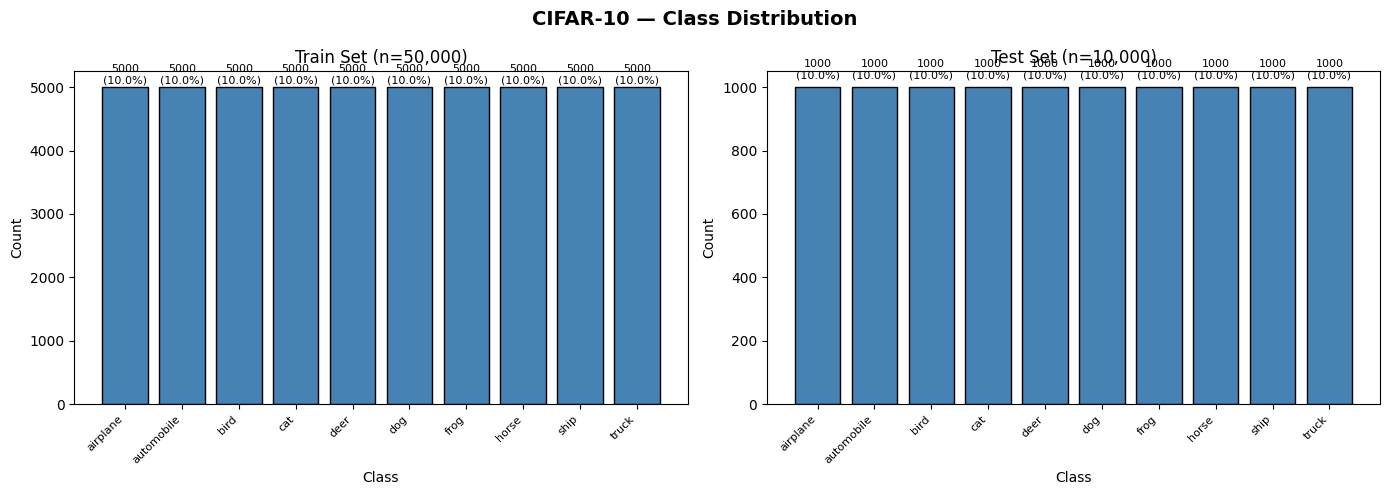


Train — min: 5000 | max: 5000 | ratio: 1.00x
Test  — min: 1000 | max: 1000 | ratio: 1.00x

Perfectly balanced: True


In [3]:
# Step 2: Class distribution
print("=" * 60)
print("[2/8] CLASS DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in [(axes[0], y_train, 'Train'), (axes[1], y_test, 'Test')]:
    unique, counts = np.unique(labels, return_counts=True)
    bars = ax.bar(unique, counts, color='steelblue', edgecolor='black')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Set (n={len(labels):,})')
    ax.set_xticks(unique)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)

    # Annotate bars with count + percentage
    for bar, count in zip(bars, counts):
        pct = count / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

plt.suptitle('CIFAR-10 — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Balance check
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)
print(f"\nTrain — min: {train_counts.min()} | max: {train_counts.max()} | ratio: {train_counts.max() / train_counts.min():.2f}x")
print(f"Test  — min: {test_counts.min()} | max: {test_counts.max()} | ratio: {test_counts.max() / test_counts.min():.2f}x")
print(f"\nPerfectly balanced: {train_counts.min() == train_counts.max() and test_counts.min() == test_counts.max()}")

[3/8] SAMPLE VISUALIZATION


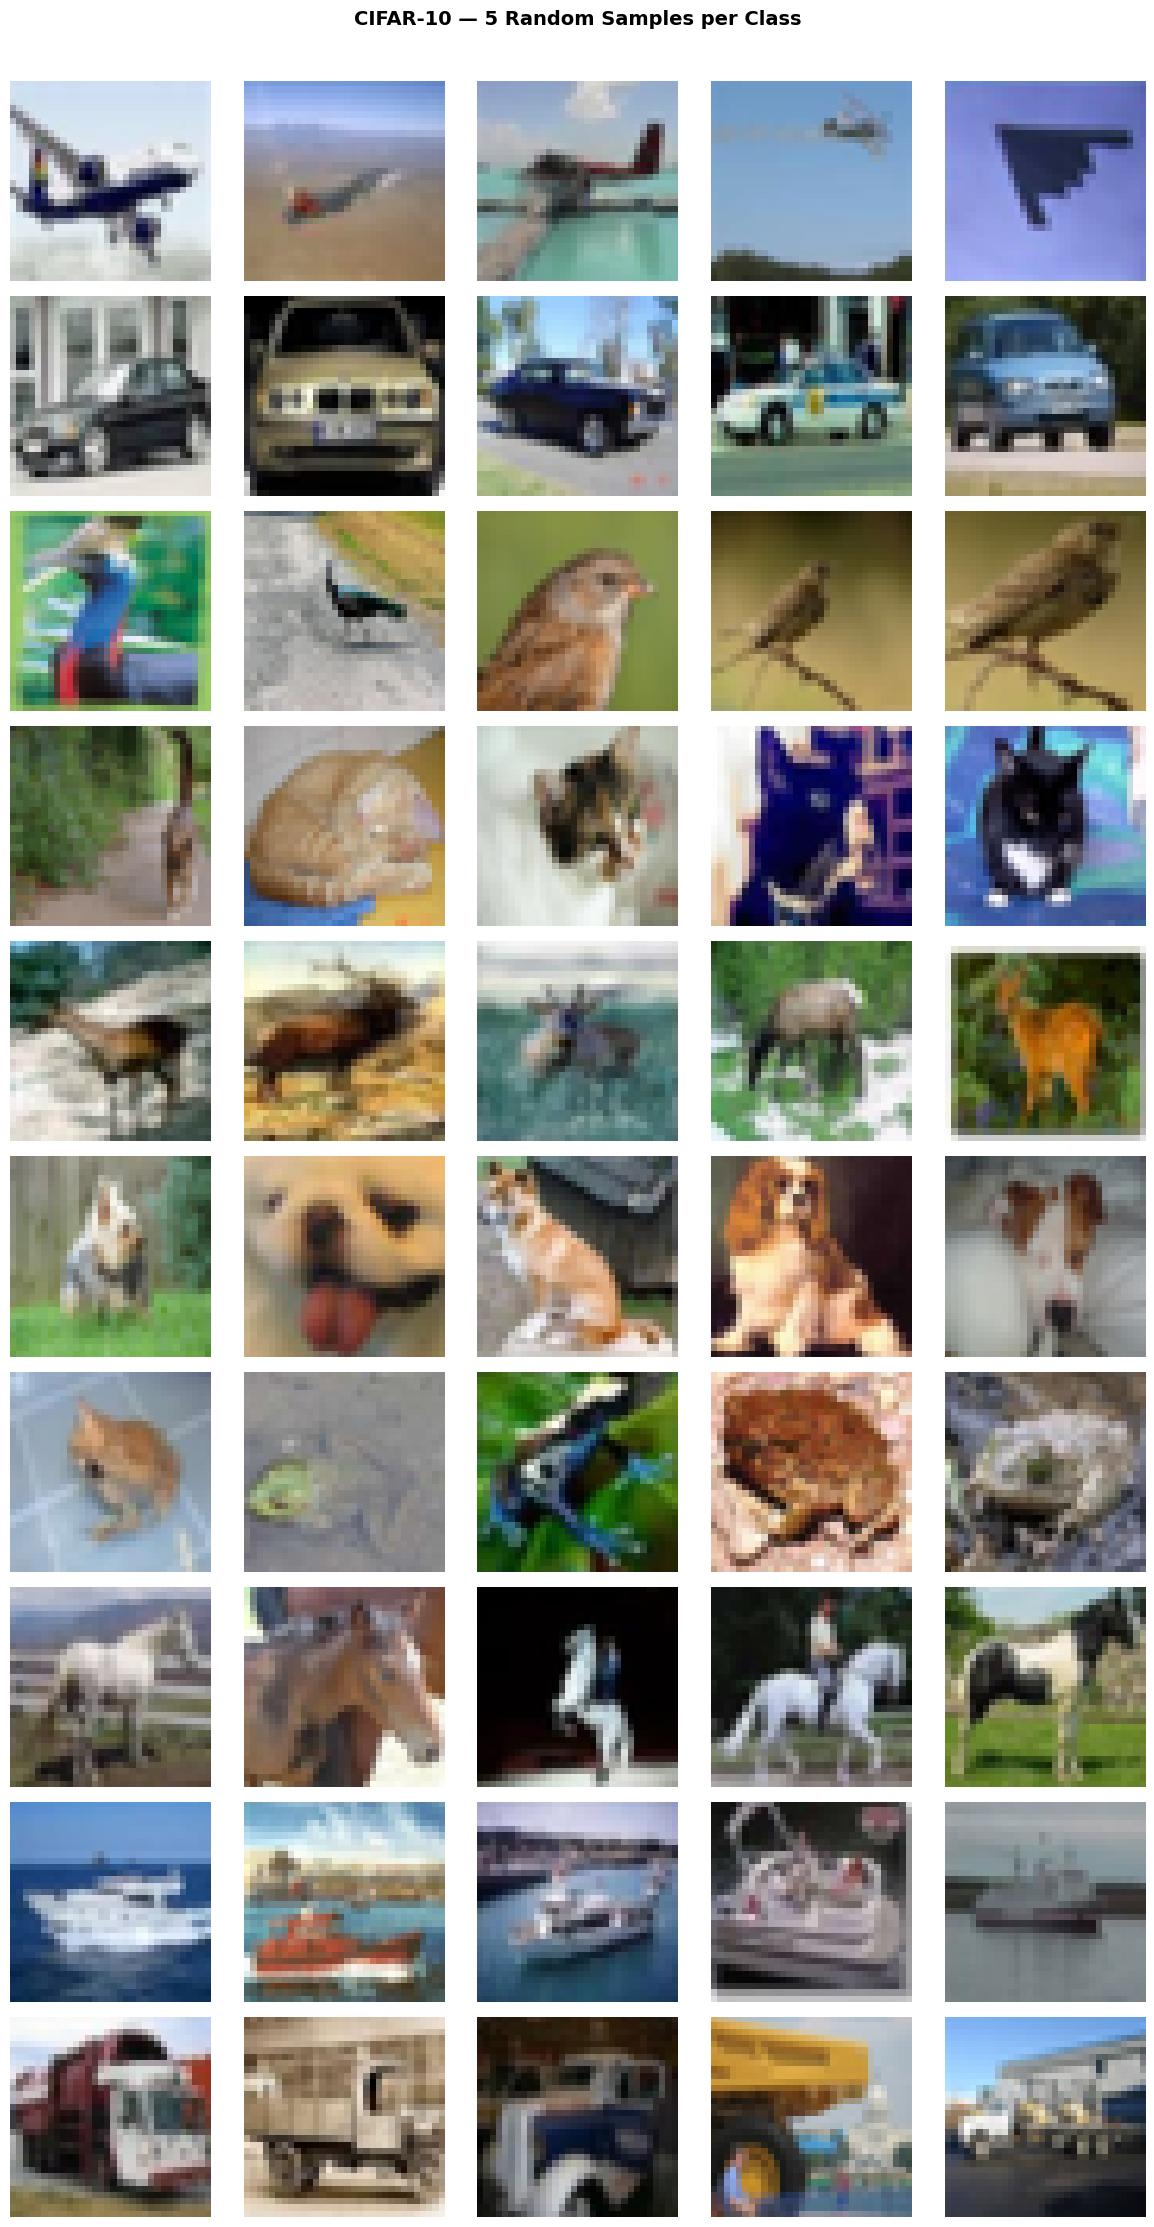


Visual observations:
    - Images are 32x32 — low resolution, objects fill most of the frame
    - Background varies significantly (sky, grass, water, indoor)
    - Some classes have high intra-class variation (bird, cat, dog)
    - Man-made objects (airplane, automobile, ship, truck) have more consistent shapes


In [4]:
# Step 3: Sample visualization — 5 random images per class
print("=" * 60)
print("[3/8] SAMPLE VISUALIZATION")
print("=" * 60)

fig, axes = plt.subplots(10, 5, figsize=(12, 22))

for row, class_idx in enumerate(range(10)):
    # Get indices for this class
    class_mask = y_train == class_idx
    class_indices = np.where(class_mask)[0]
    
    # Random sample of 5
    rng = np.random.RandomState(RANDOM_STATE + class_idx)
    sample_idx = rng.choice(class_indices, size=5, replace=False)
    
    for col, idx in enumerate(sample_idx):
        axes[row, col].imshow(X_train_raw[idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CLASS_NAMES[class_idx], fontsize=11,
                                       rotation=0, labelpad=70, va='center')

plt.suptitle('CIFAR-10 — 5 Random Samples per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/sample_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisual observations:")
print("    - Images are 32x32 — low resolution, objects fill most of the frame")
print("    - Background varies significantly (sky, grass, water, indoor)")
print("    - Some classes have high intra-class variation (bird, cat, dog)")
print("    - Man-made objects (airplane, automobile, ship, truck) have more consistent shapes")

[4/8] PIXEL INTENSITY DISTRIBUTION

Per-channel statistics (train set):
Channel        Mean      Std    Min    Max
------------------------------------------
Red          125.31    62.99      0    255
Green        122.95    62.09      0    255
Blue         113.87    66.70      0    255


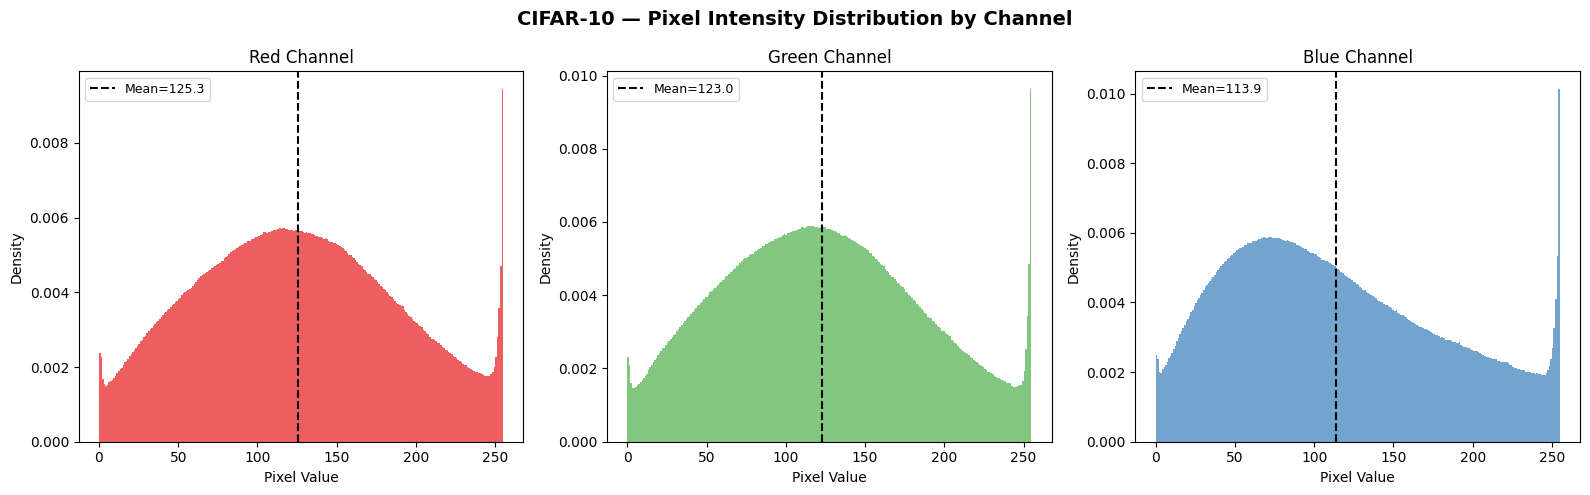


Channel correlation (train set, sampled 10K images):
    R-G: 0.9121
    R-B: 0.7865
    G-B: 0.9101
    High correlation → channels carry redundant info → compression opportunity


In [5]:
# Step 4: Pixel intensity distribution — per-channel analysis
print("=" * 60)
print("[4/8] PIXEL INTENSITY DISTRIBUTION")
print("=" * 60)

# Per-channel statistics
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#e41a1c', '#4daf4a', '#377eb8']

print("\nPer-channel statistics (train set):")
print(f"{'Channel':<10} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 42)
for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    ch = X_train_raw[:, :, :, i].astype(np.float32)
    print(f"{name:<10} {ch.mean():>8.2f} {ch.std():>8.2f} {ch.min():>6.0f} {ch.max():>6.0f}")

# Per-channel histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    ch_data = X_train_raw[:, :, :, i].flatten()
    axes[i].hist(ch_data, bins=256, range=(0, 255), color=color, alpha=0.7, density=True)
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{name} Channel', fontsize=12)
    axes[i].axvline(ch_data.mean(), color='black', linestyle='--', linewidth=1.5,
                     label=f'Mean={ch_data.mean():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('CIFAR-10 — Pixel Intensity Distribution by Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Channel correlation
print("\nChannel correlation (train set, sampled 10K images):")
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_raw), 10000, replace=False)
sample = X_train_raw[sample_idx].reshape(-1, 3).astype(np.float32)
corr_matrix = np.corrcoef(sample.T)
print(f"    R-G: {corr_matrix[0, 1]:.4f}")
print(f"    R-B: {corr_matrix[0, 2]:.4f}")
print(f"    G-B: {corr_matrix[1, 2]:.4f}")
print("    High correlation → channels carry redundant info → compression opportunity")

[5/8] IMAGE COMPLEXITY ANALYSIS

Per-image variance (normalized [0,1]):
    Mean: 0.0476
    Std:  0.0242
    Min:  0.0014 (simplest image)
    Max:  0.2034 (most complex image)

Per-class average variance (higher = harder to reconstruct):
Class             Mean Var    Std Var
-------------------------------------
airplane            0.0450     0.0246
automobile          0.0582     0.0218
bird                0.0362     0.0218
cat                 0.0499     0.0245
deer                0.0345     0.0196
dog                 0.0498     0.0233
frog                0.0375     0.0206
horse               0.0514     0.0227
ship                0.0492     0.0228
truck               0.0642     0.0222

Easiest to reconstruct: deer (var=0.0345)
Hardest to reconstruct: truck (var=0.0642)


C:\Users\Max\AppData\Local\Temp\ipykernel_5700\1984894706.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(class_data, labels=CLASS_NAMES, patch_artist=True)


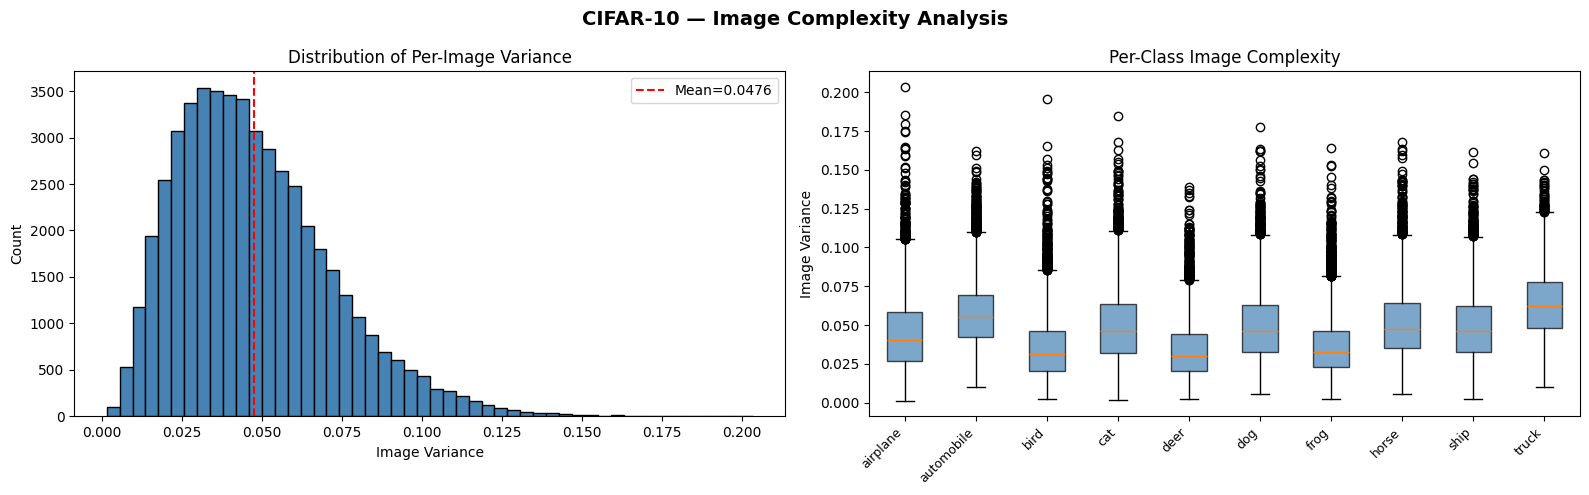

In [6]:
# Step 5: Image complexity analysis — per-image variance
print("=" * 60)
print("[5/8] IMAGE COMPLEXITY ANALYSIS")
print("=" * 60)

# Per-image variance (higher = more complex/detailed)
train_float = X_train_raw.astype(np.float32) / 255.0
per_image_var = train_float.reshape(len(train_float), -1).var(axis=1)

print(f"\nPer-image variance (normalized [0,1]):")
print(f"    Mean: {per_image_var.mean():.4f}")
print(f"    Std:  {per_image_var.std():.4f}")
print(f"    Min:  {per_image_var.min():.4f} (simplest image)")
print(f"    Max:  {per_image_var.max():.4f} (most complex image)")

# Per-class average variance — which classes are harder to reconstruct?
print(f"\nPer-class average variance (higher = harder to reconstruct):")
print(f"{'Class':<15} {'Mean Var':>10} {'Std Var':>10}")
print("-" * 37)
class_vars = []
for i, name in enumerate(CLASS_NAMES):
    mask = y_train == i
    cls_var = per_image_var[mask]
    class_vars.append(cls_var.mean())
    print(f"{name:<15} {cls_var.mean():>10.4f} {cls_var.std():>10.4f}")

# Sort by complexity
sorted_idx = np.argsort(class_vars)
print(f"\nEasiest to reconstruct: {CLASS_NAMES[sorted_idx[0]]} (var={class_vars[sorted_idx[0]]:.4f})")
print(f"Hardest to reconstruct: {CLASS_NAMES[sorted_idx[-1]]} (var={class_vars[sorted_idx[-1]]:.4f})")

# Visualize: variance distribution + per-class boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overall distribution
axes[0].hist(per_image_var, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Image Variance')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Per-Image Variance', fontsize=12)
axes[0].axvline(per_image_var.mean(), color='red', linestyle='--',
                label=f'Mean={per_image_var.mean():.4f}')
axes[0].legend()

# Right: per-class boxplot
class_data = [per_image_var[y_train == i] for i in range(10)]
bp = axes[1].boxplot(class_data, labels=CLASS_NAMES, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Image Variance')
axes[1].set_title('Per-Class Image Complexity', fontsize=12)

plt.suptitle('CIFAR-10 — Image Complexity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/image_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

[6/8] SPATIAL STRUCTURE


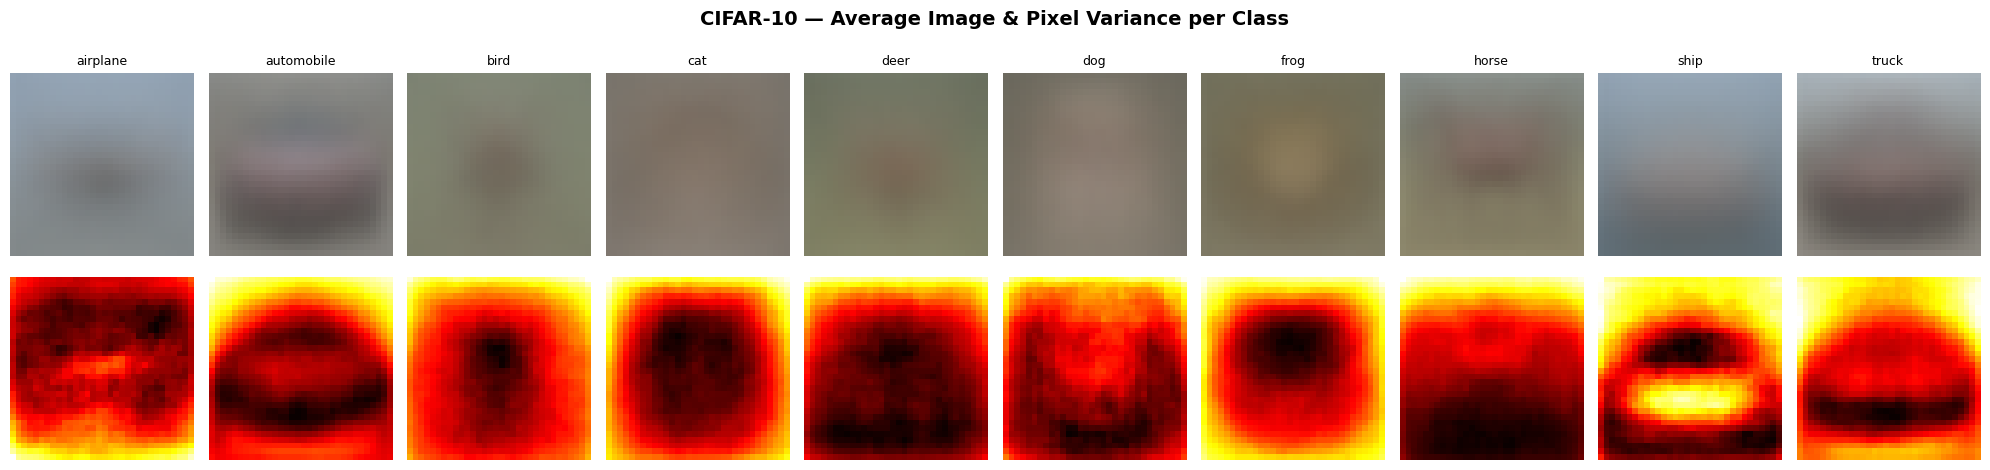


Spatial observations:
    - Mean images show class 'templates' — airplane/ship have blue backgrounds (sky/water)
    - Frog/deer show green backgrounds (nature scenes)
    - Variance maps highlight edges and object boundaries — where reconstruction error concentrates
    - Uniform background classes (frog, deer) will have lower reconstruction MSE
    - High-variance edges are the hardest pixels to reconstruct accurately


In [7]:
# Step 6: Spatial structure — average image + variance map per class
print("=" * 60)
print("[6/8] SPATIAL STRUCTURE")
print("=" * 60)

train_float = X_train_raw.astype(np.float32) / 255.0

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, name in enumerate(CLASS_NAMES):
    mask = y_train == i
    class_images = train_float[mask]
    
    # Mean image — shows structural "template" for each class
    mean_img = class_images.mean(axis=0)
    axes[0, i].imshow(mean_img)
    axes[0, i].axis('off')
    axes[0, i].set_title(name, fontsize=9)
    
    # Variance map — shows where variation concentrates (edges, textures)
    var_img = class_images.var(axis=0).mean(axis=2)  # average across channels
    axes[1, i].imshow(var_img, cmap='hot')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Mean', fontsize=11, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('Variance', fontsize=11, rotation=0, labelpad=40, va='center')

plt.suptitle('CIFAR-10 — Average Image & Pixel Variance per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/spatial_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSpatial observations:")
print("    - Mean images show class 'templates' — airplane/ship have blue backgrounds (sky/water)")
print("    - Frog/deer show green backgrounds (nature scenes)")
print("    - Variance maps highlight edges and object boundaries — where reconstruction error concentrates")
print("    - Uniform background classes (frog, deer) will have lower reconstruction MSE")
print("    - High-variance edges are the hardest pixels to reconstruct accurately")

In [8]:
# Step 7: Dimensionality considerations — compression ratios
print("=" * 60)
print("[7/8] DIMENSIONALITY CONSIDERATIONS")
print("=" * 60)

n_features = 3072  # 32 x 32 x 3
latent_dims = [32, 64, 128, 256, 512]

print(f"\nInput dimensionality: {n_features} features (32 × 32 × 3)")
print(f"\nCompression ratios for candidate latent dimensions:")
print(f"{'Latent Dim':>12} {'Compression':>14} {'% of Original':>16}")
print("-" * 44)
for dim in latent_dims:
    ratio = n_features / dim
    pct = dim / n_features * 100
    print(f"{dim:>12} {ratio:>13.1f}x {pct:>15.1f}%")

# Compare to PCA (Fashion-MNIST)
print(f"\nComparison to PCA (Fashion-MNIST):")
print(f"    PCA: 784 → 150 features = 5.2x compression (90.85% variance retained)")
print(f"    AE:  3,072 → 128 features = 24.0x compression (quality TBD)")
print(f"    CIFAR-10 is 3.9x more features and RGB — much harder compression task")

# Estimate parameter counts for dense autoencoder at each latent dim
print(f"\nEstimated parameters for dense AE (3072-512-dim-512-3072):")
print(f"{'Latent Dim':>12} {'Parameters':>14} {'Model Size (MB)':>16}")
print("-" * 44)
for dim in latent_dims:
    # Encoder: 3072*512 + 512 + 512*dim + dim
    # Decoder: dim*512 + 512 + 512*3072 + 3072
    params = (3072 * 512 + 512) + (512 * dim + dim) + (dim * 512 + 512) + (512 * 3072 + 3072)
    size_mb = params * 4 / (1024 ** 2)  # float32
    print(f"{dim:>12} {params:>14,} {size_mb:>15.2f}")

print(f"\nKey insight: Dense AE is parameter-heavy (~3.2M+ params) because the")
print(f"input is 3,072-dimensional. Conv AE will be much more efficient by")
print(f"exploiting spatial locality (shared filters instead of full connections).")

[7/8] DIMENSIONALITY CONSIDERATIONS

Input dimensionality: 3072 features (32 × 32 × 3)

Compression ratios for candidate latent dimensions:
  Latent Dim    Compression    % of Original
--------------------------------------------
          32          96.0x             1.0%
          64          48.0x             2.1%
         128          24.0x             4.2%
         256          12.0x             8.3%
         512           6.0x            16.7%

Comparison to PCA (Fashion-MNIST):
    PCA: 784 → 150 features = 5.2x compression (90.85% variance retained)
    AE:  3,072 → 128 features = 24.0x compression (quality TBD)
    CIFAR-10 is 3.9x more features and RGB — much harder compression task

Estimated parameters for dense AE (3072-512-dim-512-3072):
  Latent Dim     Parameters  Model Size (MB)
--------------------------------------------
          32      3,182,624           12.14
          64      3,215,424           12.27
         128      3,281,024           12.52
         256   

[8/8] NOISE PREVIEW — DENOISING TASK


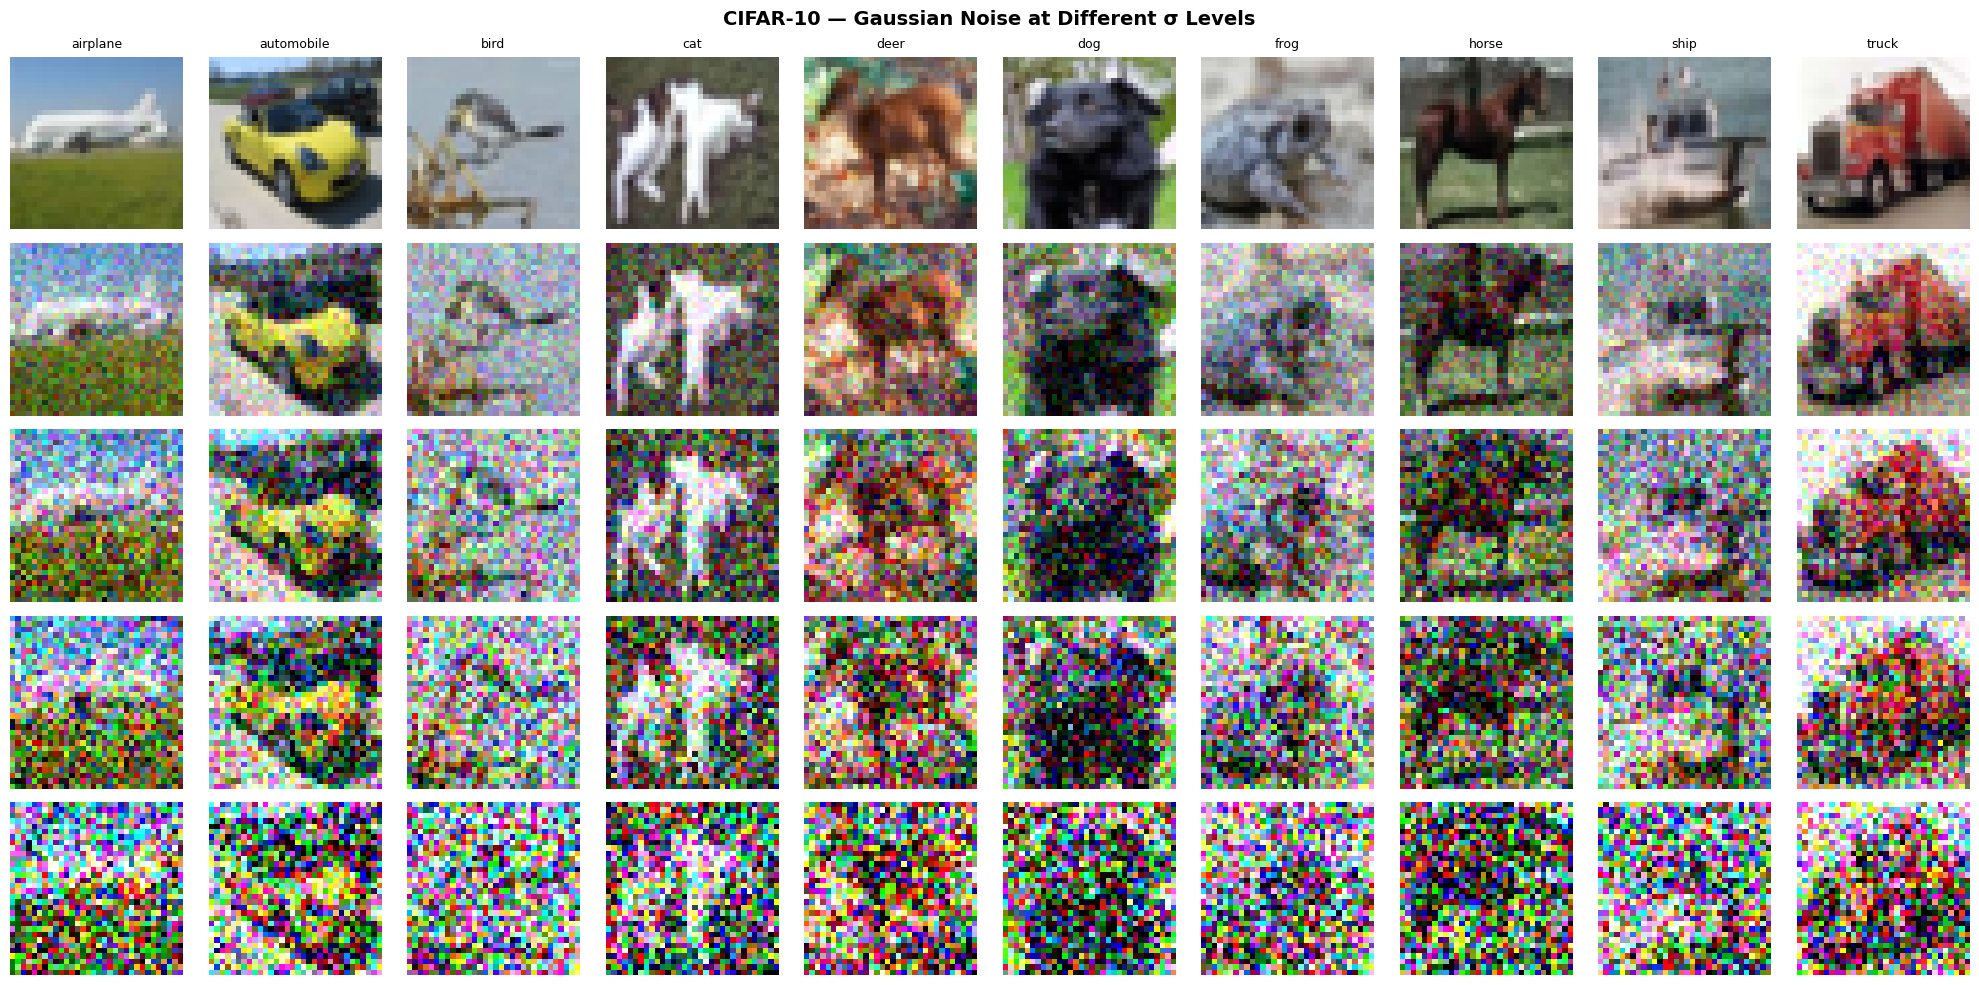


Noise impact on reconstruction difficulty:
   Sigma   MSE vs Clean    PSNR (dB)
------------------------------------
     0.1         0.0095       20.23
     0.2         0.0342       14.66
     0.3         0.0655       11.84
     0.5         0.1224        9.12

Denoising task: autoencoder receives noisy input, must reconstruct clean original.
σ=0.3 is a good default — visible corruption but object still recognizable.
σ=0.5 pushes the limit — heavy noise, tests robustness.


In [9]:
# Step 8: Noise preview — visualize denoising task at different sigma levels
print("=" * 60)
print("[8/8] NOISE PREVIEW — DENOISING TASK")
print("=" * 60)

# Pick one sample image per class for consistent comparison
rng = np.random.RandomState(RANDOM_STATE)
sample_indices = []
for i in range(10):
    class_idx = np.where(y_train == i)[0]
    sample_indices.append(rng.choice(class_idx))

sample_images = X_train_raw[sample_indices].astype(np.float32) / 255.0

# Noise levels to preview
sigmas = [0.0, 0.1, 0.2, 0.3, 0.5]
sigma_labels = ['Original', 'σ=0.1', 'σ=0.2', 'σ=0.3', 'σ=0.5']

fig, axes = plt.subplots(len(sigmas), 10, figsize=(20, 10))

for row, (sigma, label) in enumerate(zip(sigmas, sigma_labels)):
    for col in range(10):
        img = sample_images[col].copy()
        if sigma > 0:
            noise = rng.randn(*img.shape).astype(np.float32) * sigma
            img = np.clip(img + noise, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=11, rotation=0,
                                       labelpad=50, va='center')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], fontsize=9)

plt.suptitle('CIFAR-10 — Gaussian Noise at Different σ Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/noise_preview.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify noise impact on pixel MSE
print("\nNoise impact on reconstruction difficulty:")
print(f"{'Sigma':>8} {'MSE vs Clean':>14} {'PSNR (dB)':>12}")
print("-" * 36)
for sigma in [0.1, 0.2, 0.3, 0.5]:
    noise = rng.randn(*sample_images.shape).astype(np.float32) * sigma
    noisy = np.clip(sample_images + noise, 0, 1)
    mse = np.mean((sample_images - noisy) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')
    print(f"{sigma:>8.1f} {mse:>14.4f} {psnr:>11.2f}")

print("\nDenoising task: autoencoder receives noisy input, must reconstruct clean original.")
print("σ=0.3 is a good default — visible corruption but object still recognizable.")
print("σ=0.5 pushes the limit — heavy noise, tests robustness.")

In [10]:
# EDA Summary
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print("""
DATASET: CIFAR-10
    - 60,000 color images (50,000 train / 10,000 test)
    - 32×32×3 = 3,072 features (flattened)
    - 10 classes (labels for evaluation only — autoencoders are self-supervised)
    - Perfectly balanced: 5,000/class train, 1,000/class test

DATA QUALITY:
    - Zero NaNs, zero Infs, zero duplicates
    - uint8 [0, 255] — standard pixel range
    - No cross-set leakage confirmed

PIXEL DISTRIBUTION:
    - Channel means: R=125.3, G=123.0, B=113.9 (centered, not zero-mean)
    - High inter-channel correlation: R-G 0.91, G-B 0.91, R-B 0.79
    - Redundancy across channels → compression opportunity for autoencoder

IMAGE COMPLEXITY:
    - Mean variance: 0.0476 (normalized [0,1])
    - Easiest class: deer (var=0.0345) — uniform green backgrounds
    - Hardest class: truck (var=0.0642) — diverse scenes, high edge density
    - Variance maps show reconstruction error will concentrate at object edges

SPATIAL STRUCTURE:
    - Mean images reveal class templates (centered objects, consistent backgrounds)
    - Conv filters will exploit local spatial patterns that dense layers cannot

COMPRESSION ANALYSIS:
    - 3,072 → 128 latent = 24x compression (much harder than PCA's 5.2x)
    - Dense AE: ~3.2M+ params (dominated by 3072→512 input layer)
    - Conv AE: ~200-400K params (shared filters, spatial locality)

DENOISING TASK:
    - σ=0.1: mild noise (MSE=0.0095, PSNR=20.2 dB) — objects clearly visible
    - σ=0.3: heavy noise (MSE=0.0655, PSNR=11.8 dB) — good default challenge
    - σ=0.5: extreme noise (MSE=0.1224, PSNR=9.1 dB) — robustness stress test

PREPROCESSING DECISIONS:
    1. Normalize to [0, 1] (divide by 255) — NOT StandardScaler
       Reason: autoencoder sigmoid output maps to [0,1], reconstruction in pixel space
    2. Save flattened (3072) for dense AE + image-shaped (32,32,3) for conv AE
    3. No class weighting — perfectly balanced, labels only for evaluation
    4. No scaler.pkl — inverse transform is identity (clip to [0,1])
    5. Noise added at training time, not preprocessing (augmentation strategy)
    6. Use built-in 50K/10K split (no manual splitting)
""")

EDA SUMMARY — KEY FINDINGS

DATASET: CIFAR-10
    - 60,000 color images (50,000 train / 10,000 test)
    - 32×32×3 = 3,072 features (flattened)
    - 10 classes (labels for evaluation only — autoencoders are self-supervised)
    - Perfectly balanced: 5,000/class train, 1,000/class test

DATA QUALITY:
    - Zero NaNs, zero Infs, zero duplicates
    - uint8 [0, 255] — standard pixel range
    - No cross-set leakage confirmed

PIXEL DISTRIBUTION:
    - Channel means: R=125.3, G=123.0, B=113.9 (centered, not zero-mean)
    - High inter-channel correlation: R-G 0.91, G-B 0.91, R-B 0.79
    - Redundancy across channels → compression opportunity for autoencoder

IMAGE COMPLEXITY:
    - Mean variance: 0.0476 (normalized [0,1])
    - Easiest class: deer (var=0.0345) — uniform green backgrounds
    - Hardest class: truck (var=0.0642) — diverse scenes, high edge density
    - Variance maps show reconstruction error will concentrate at object edges

SPATIAL STRUCTURE:
    - Mean images reveal clas